
# A Dashboard for the GRACEFUL17 Knowledge Graph

In the following, we provide an overview of the data from the **GRACEFUL17** project (Global Governance, Local Dynamics. Transnational Regimes of Grace in the Roman Dataria Apostolica (17th Century)) (https://graceful17.hypotheses.org), which is financed by the by **Deutsche Forschungsgemeinschaft** (DFG) under Grant 510246510 and the **Agence nationale de la recherche** (ANR) as part of the *Appel à projets franco-allemand en sciences humaines et sociales* under Grant ANR-22-FRAL-0010. The project is jointly directed by Olivier Poncet (*École nationale des chartes, Paris*) and Birgit Emich (*Goethe University Frankfurt*), with Bruno Boute (*Goethe University Frankfurt*) as the principal investigator. The Digital Humanities component is led by Jörg Hörnschmeyer and Christoph Sander (both *German Historical Institute Rome*). The team is complemented by three doctoral students: Valentino Verdone (*Goethe University Frankfurt*), Filippo Sarra (*École nationale des chartes Paris*) and Naomi Beutler (*École nationale des chartes Paris*/*Universitat Autònoma de Barcelona*).

GRACEFUL17 aims to study papal provisions of ecclesiastical offices, mainly benefices, in the modern era from a global perspective. Combining classical paleographic skills and new competences derived by Digital Humanities, the team project has built an Ontology (see https://doi.org/10.5281/zenodo.17420005 and https://dhi-roma.github.io/grace-ontology/docs/widoco/doc/index.html), based on collecting and modelling data in the *Archivio Apostolico Vaticano*. Here, we cannot offer a full methodological explanation of how the collected data has been structured. However, a dedicated data paper is available, which outlines our approach and demonstrates how scholars may draw on our dataset for their own research.
The aim of this dashboard is to provide an overview of our work through a series of SPARQL queries.


## <font color="green">Imports</font>

We import minimal dependencies, most importantly the [DATAria utilities](https://github.com/ch-sander/dataria-py-utils)

In [1]:
# @title
!pip install dataria itables -qqq

In [2]:
import dataria, itables
from matplotlib import pyplot as plt
import seaborn as sns
itables.init_notebook_mode()
endpoint_url="https://graph.dhi-roma.it/query"

## <font color="green">1. Metadata</font>

### <font color="blue">1.1 Contributors</font>

This notebook was created by (see contributor list below):


*   Queries: [Christoph Sander](https://orcid.org/0000-0003-4452-0107), [Naomi Beutler](https://orcid.org/0009-0005-1361-5092), [Filippo Sarra](https://orcid.org/0009-0009-4366-4011), [Valentino Verdone](https://orcid.org/0009-0000-7424-5770)
*   Explanations: [Christoph Sander](https://orcid.org/0000-0003-4452-0107), [Naomi Beutler](https://orcid.org/0009-0005-1361-5092), [Filippo Sarra](https://orcid.org/0009-0009-4366-4011), [Valentino Verdone](https://orcid.org/0009-0000-7424-5770)
*   Visuals: [Christoph Sander](https://orcid.org/0000-0003-4452-0107), [Naomi Beutler](https://orcid.org/0009-0005-1361-5092)

---



The contributors listed in the following query worked on this dataset, its collection, processing, curation, and the design of the database and knowledge graph (using [CRediT](http://credit.niso.org/)).

### <font color="blue">1.2 Contributors to the dataset</font>

The creation of the dataset was part of the GRACEFUL17 project as a whole for which we credit the following contributors.

In [3]:
sparql_contributors = """
PREFIX schema: <https://schema.org/>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT DISTINCT ?Contributor ?ORCID (GROUP_CONCAT(DISTINCT ?label; SEPARATOR = " & ") AS ?credits) WHERE {
  ?contribution a schema:Role; owl:sameAs ?credit; schema:name ?label; ^schema:role ?contributor.
  ?contributor schema:name ?Contributor.
  OPTIONAL {?contributor schema:sameAs ?ORCID.}
} GROUP BY ?Contributor ?ORCID
ORDER BY (?Contributor)
"""

In [4]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_contributors)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### <font color="blue">1.3 Timestamp of the data</font>

The underlying data is frequently updated. To keep track of which data was used for the subsequent queries, we retrieve the eariles and the latest timestamp in all data.

In [5]:
time_stamp="""
PREFIX prov: <http://www.w3.org/ns/prov#>
SELECT (MIN(?date) AS ?earliest) (MAX(?date) AS ?latest)
WHERE {
  ?entity prov:generatedAtTime ?date .
}
"""

In [6]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=time_stamp)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## <font color="green">2. Sources and archives</font>



The project GRACEFUL17 focusses on two latin manuscripts belonging to the *Expeditiones* serie which pertains to the Dataria dicastery in the Vatican Archive. These sources from the 17th century contain some resumes of *graces* mainly apostolic provisions.

### <font color="blue">2.1 All sources included in the data set</font>

The first query displays all sources contained in our knowledge graph (including those beyond the Dataria dicastery). The first column shows the number of entries, the second lists the name of the archive, and the third provides the name of the source.

In [7]:
sparql_entries_per_source_and_archive = """
# SPARQL query: number of entries per source and archive
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?ENTRY) AS ?ENTRIES) ?ARCHIVE ?SOURCE WHERE {
  ?ENTRY rdf:type grace:entry;
    grace:called ?ENTRY_label;
    grace:in_source ?SOURCE_IRI.
  ?SOURCE_IRI rdf:type grace:source;
    grace:called ?SOURCE;
    grace:in_archive ?ARCHIVE_IRI.
  ?ARCHIVE_IRI rdf:type grace:archive;
    grace:called ?ARCHIVE.
}
GROUP BY ?ARCHIVE_IRI ?ARCHIVE ?SOURCE_IRI ?SOURCE
ORDER BY DESC (?ENTRIES)
"""

In [8]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_entries_per_source_and_archive)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


 ### <font color="blue">2.2 Sources from the Vatican Apostolic Archive</font>

 The query returns all the sources in the dataset belonging to the *Archivio Apostolico Vaticano*

In [9]:
sparql_entries_per_source_Dataria_Apostolica = """
# SPARQL query: number of entries per source Dataria Apostolica
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?ENTRY_9) AS ?ENTRIES) ?ARCHIVE ?SOURCE WHERE {
  ?EVENT_1 rdf:type grace:event;
    grace:event_related_to_object ?OBJECT_2.
  ?OBJECT_2 rdf:type grace:object.
  FILTER(NOT EXISTS {
    ?EVENT_1 grace:executor ?PERSON.
    ?PERSON rdf:type grace:person;
      grace:called ?PERSON_label.
  })
  ?EVENT_1 grace:type_of_event ?TYPE_6.
  VALUES ?TYPE_6 {
    g17:type_1
    g17:type_1332
    g17:type_1105
  }
  ?EVENT_1 grace:testified_by ?ENTRY_9.
  ?ENTRY_9 rdf:type grace:entry;
    grace:called ?ENTRY_9_label;
    grace:in_source ?SOURCE_IRI.
  ?SOURCE_IRI rdf:type grace:source;
    grace:called ?SOURCE;
    grace:in_archive ?ARCHIVE_IRI.
  ?ARCHIVE_IRI grace:called ?ARCHIVE.
  VALUES ?ARCHIVE_IRI {
    g17:archive_1
  }
}
GROUP BY ?PERSON ?PERSON_label ?ARCHIVE_IRI ?ARCHIVE ?SOURCE_IRI ?SOURCE
ORDER BY DESC (?ENTRIES)
"""


In [10]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_entries_per_source_Dataria_Apostolica)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### <font color="blue">2.3 *Expeditiones* register 2 (1622/23) and 9 (1677/78)</font>

In the next query we specify the number of entries for *Expeditiones* volumes number 2 (1622/23) and 9 (1677/78), which represent the core of the data. We display here the number of entries with their corresponding year. Both sources are accessible at the *Archivio Apostolico Vaticano*.

In [ ]:
sparql_entries_per_source_Expedit_nine_and_two = """
# SPARL query: number of entries per year and source Expedit. 9 and 2
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
PREFIX g17raw: <https://g17.dhi-roma.it/raw/>
SELECT DISTINCT (COUNT(DISTINCT ?ENTRY_1) AS ?ENTRIES) ?SOURCE ?DATE ?ARCHIVE WHERE {
  ?ENTRY_1 rdf:type grace:entry;
    grace:called ?ENTRY;
    grace:in_source ?SOURCE_2.
  ?SOURCE_2 grace:called ?SOURCE.
  VALUES ?SOURCE_2 {
    g17:source_1
    g17:source_2
  }
  ?ENTRY_1 grace:testifies_to ?EVENT_4.
  ?EVENT_4 rdf:type grace:event;
    grace:event_date ?DATE_6.
  ?DATE_6 rdf:type grace:date;
    g17raw:start_date_year ?DATE.
  ?ENTRY_1 grace:in_source ?SOURCE_10.
  ?SOURCE_10 rdf:type grace:source;
    grace:in_archive ?ARCHIVE_12.
  ?ARCHIVE_12 grace:called ?ARCHIVE.
  VALUES ?ARCHIVE_12 {
    g17:archive_1
  }
}
GROUP BY ?SOURCE_2 ?SOURCE ?DATE ?ARCHIVE_12 ?ARCHIVE
ORDER BY DESC (?ENTRIES)
"""

In [12]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_entries_per_source_Expedit_nine_and_two)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## <font color="green">3. Events and objects</font>

In our ontology, we designate the act of granting an apostolic provision as an event, and the benefice itself as an object, which forms the core of our model. Each event is associated with exactly one object, whereas a single object may be linked to multiple events. For instance, an ecclesiastical pension is always connected in some way to a previous benefice: the benefice object is linked to the event of granting that benefice, but it is also linked to the pension, which in turn is connected to another event — the granting of the pension.

### <font color="blue">3.1 Primary types of events</font>
To understand the next queries we need to specify that we assigned different types to the events and objects, such as "apostolic provision" and "apostolic dispensation" for events.

The first query of this section displays the number of events per primary type of event.

In [ ]:
sparql_primary_types_events = """
# SPARQL query: count of events per primary type in Expedit. 2 and 9
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?EVENT_1) AS ?EVENTS) ?TYPE WHERE {
  ?EVENT_1 rdf:type grace:event;
    grace:called ?EVENT;
    grace:has_main_type ?TYPE_2.
  ?TYPE_2 rdf:type grace:type;
    grace:called ?TYPE.
  ?EVENT_1 grace:testified_by ?ENTRY_4.
  ?ENTRY_4 rdf:type grace:entry;
    grace:in_source ?SOURCE_6.
  VALUES ?SOURCE_6 {
    g17:source_1
    g17:source_2
  }
}
GROUP BY ?TYPE_2 ?TYPE
ORDER BY DESC (?EVENTS)
"""

In [14]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_primary_types_events)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


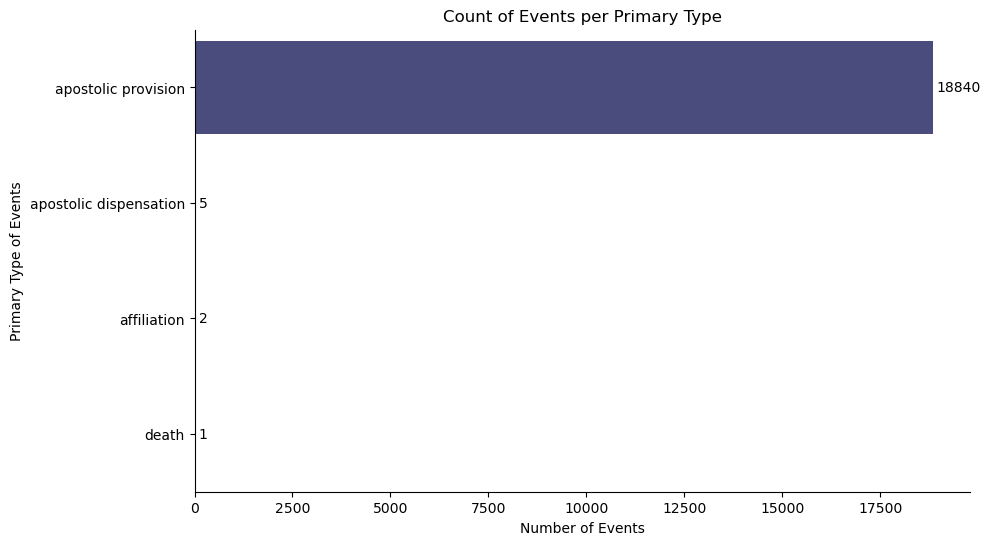

In [15]:
sparql_primary_types_events_df = dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_primary_types_events)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sparql_primary_types_events_df,
    x='EVENTS',
    y='TYPE',
    hue='TYPE',
    palette='viridis',
    legend=False
)
plt.title('Count of Events per Primary Type')
plt.xlabel('Number of Events')
plt.ylabel('Primary Type of Events')
plt.gca().spines[['top', 'right']].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.show()

### <font color="blue">3.2 Primary types of objects</font>

As with events, we have assigned types to objects, including "benefice", "pension", "absolution", "dispensation", "indult", “commenda” and "coadjutory". The number of objects per type is shown in the following query.

In [16]:
sparql_primary_types_objects = """
# SPARQL query: count of objects per primary type in Expedit. 2 and 9
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?OBJECT_1) AS ?OBJECTS)?TYPE WHERE {
  ?OBJECT_1 rdf:type grace:object;
    grace:called ?OBJECT_1_label;
    grace:type_of_object ?TYPE_2.
  ?TYPE_2 rdf:type grace:type;
    grace:called ?TYPE.
  ?OBJECT_1 grace:object_related_to_event ?EVENT_4.
  ?EVENT_4 rdf:type grace:event;
    grace:testified_by ?ENTRY_6.
  ?ENTRY_6 rdf:type grace:entry;
    grace:in_source ?SOURCE_8.
  VALUES ?SOURCE_8 {
    g17:source_1
    g17:source_2
  }
}
GROUP BY ?TYPE_2 ?TYPE
ORDER BY DESC (?OBJECTS)
"""
sparql_primary_types_objects_df=dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_primary_types_objects)

In [17]:
sparql_primary_types_objects_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


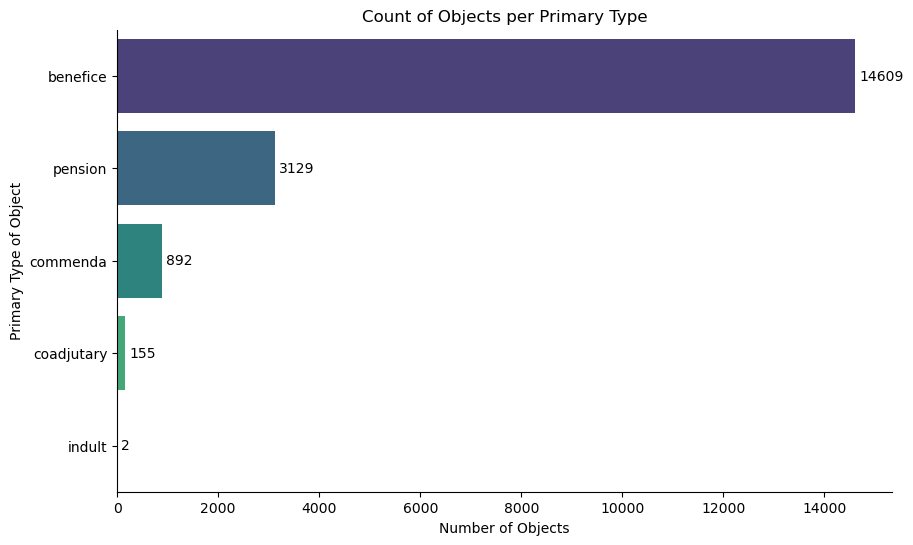

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sparql_primary_types_objects_df,
    x='OBJECTS',
    y='TYPE',
    hue='TYPE',
    palette='viridis',
    legend=False
)
plt.title('Count of Objects per Primary Type')
plt.xlabel('Number of Objects')
plt.ylabel('Primary Type of Object')
plt.gca().spines[['top', 'right']].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.show()

### <font color="blue">3.3 Temporal aggregation of events</font>

The following query displays the events per year in the *Expeditiones* registers 2 and 9 registers along with the respective pope under whose pontificate the decisions were made.

In [19]:
sparql_events_per_year = """
# SPARQL query: number of events per year (Expedit. 2 and 9) and pontificate
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
PREFIX g17raw: <https://g17.dhi-roma.it/raw/>
SELECT DISTINCT (COUNT(DISTINCT ?EVENT_1) AS ?EVENTS) ?DATE ?PERSON WHERE {
  ?EVENT_1 rdf:type grace:event;
    grace:called ?EVENT_1_label;
    (grace:testified_by/grace:in_source) ?SOURCE_2.
  VALUES ?SOURCE_2 {
    g17:source_1
    g17:source_2
  }
  ?EVENT_1 grace:event_date ?DATE_4.
  ?DATE_4 rdf:type grace:date;
    g17raw:start_date_year ?DATE.
  ?EVENT_1 grace:decided_by ?PERSON_8.
  ?PERSON_8 rdf:type grace:person;
    grace:called ?PERSON.
}
GROUP BY ?DATE ?PERSON_8 ?PERSON
ORDER BY (?DATE)
"""

sparql_events_per_year_df=dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_events_per_year)

In [20]:
sparql_events_per_year_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


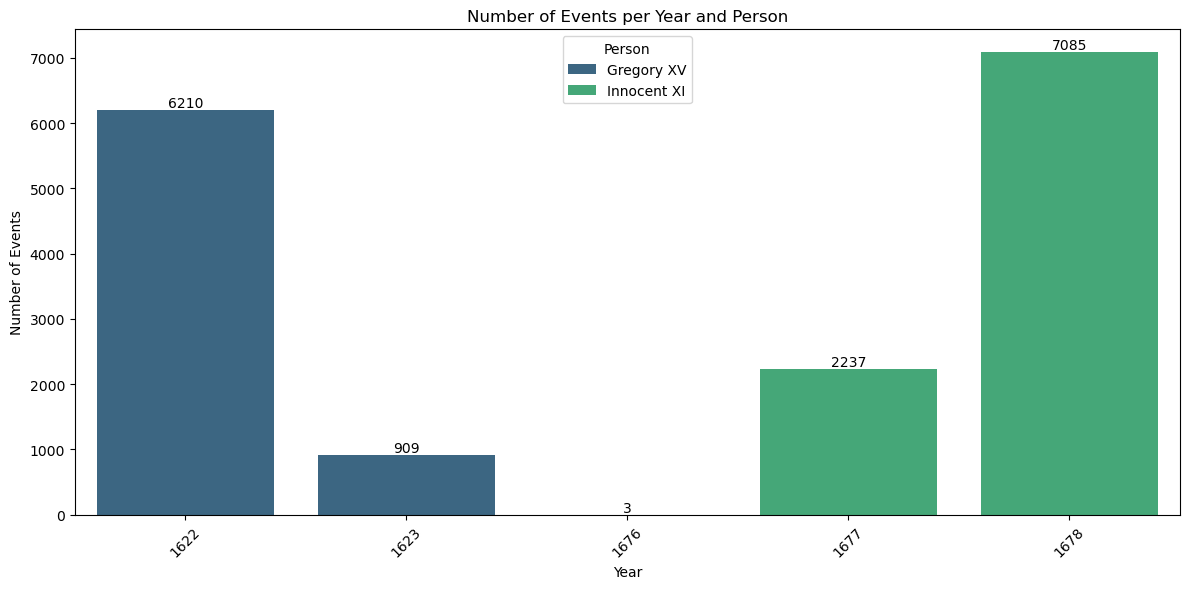

In [21]:

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=sparql_events_per_year_df, x='DATE', y='EVENTS', hue='PERSON', palette='viridis')
plt.title('Number of Events per Year and Person')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Person')
plt.tight_layout()

# Add the exact number of events to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

### <font color="blue">3.4 Ontological description of events and objects</font>

The query reveals which classes — and how many instances of each — are linked to events and objects. In other words, it identifies the specific instances of a given class that are actually used to describe events or objects. It also computes both the total number of such instances and, for each event or object, the minimum, maximum, and average number of linked instances. Overall, the query provides insight into how the formal ontology has been applied in practice to semantically describe events and objects.

In [ ]:
descriptions_per_grace = """
# SPARQL query: average number of attributes present for events
# Class Instances per Event
# Written by Christoph Sander, last modified 9. Oct 2025, 16:52

PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>

SELECT
  ?MAIN_PROPERTY
  (SUM(?descCountPerGrace) AS ?totalDescriptions)
  (MIN(?descCountPerGrace) AS ?minDescriptionsPerGrace)
  (MAX(?descCountPerGrace) AS ?maxDescriptionsPerGrace)
  (ROUND(AVG(?descCountPerGrace) * 100) / 100 AS ?avgDescriptionsPerGrace)
WHERE {
  {
    SELECT
      ?MAIN_PROPERTY
      ?PAPAL_GRACE_7
      (COUNT(DISTINCT ?DESCRIPTION_4) AS ?descCountPerGrace)
    WHERE {
      ?MAIN_PROPERTY_IRI rdf:type grace:main_property ;
                       grace:called ?MAIN_PROPERTY ;
                       ^grace:has_top_term ?MAIN_PROPERTY_2 .
      ?MAIN_PROPERTY_2 rdf:type grace:main_property ;
                       ^grace:regards ?DESCRIPTION_4 .
      ?DESCRIPTION_4 rdf:type grace:description ;
                     ^grace:described_by ?PAPAL_GRACE_7 .
      ?PAPAL_GRACE_7 rdf:type grace:papal_grace .
      FILTER(NOT EXISTS { ?MAIN_PROPERTY_IRI grace:has_top_term g17:type_173. })
    }
    GROUP BY ?MAIN_PROPERTY_IRI ?MAIN_PROPERTY ?PAPAL_GRACE_7
  }
}
GROUP BY ?MAIN_PROPERTY
ORDER BY DESC (?avgDescriptionsPerGrace)
"""

In [23]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=descriptions_per_grace)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Based on an example object, the following query shows all attributes and their average number

In [24]:
descriptions_per_object = """
# SPARQL query: average number of attributes present for events
# template query id 62
# Written by Christoph Sander, last modified 9. Oct 2025, 16:52

# Class Instances per Object
# The query shows how richly each main property is represented across immaterial objects, identifying which ones tend to be linked with many or only few instances of respective classes.
######### QUERY ##########
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>

SELECT
  ?MAIN_PROPERTY
  (SUM(?descCountPerObject) AS ?totalDescriptions)
  (MIN(?descCountPerObject) AS ?minDescriptionsPerObject)
  (MAX(?descCountPerObject) AS ?maxDescriptionsPerObject)
  (ROUND(AVG(?descCountPerObject) * 100) / 100 AS ?avgDescriptionsPerObject)
WHERE {
  {
    SELECT
      ?MAIN_PROPERTY
      ?OBJECT
      (COUNT(DISTINCT ?DESCRIPTION_4) AS ?descCountPerObject)
    WHERE {
      ?MAIN_PROPERTY_IRI rdf:type grace:main_property ;
                       grace:called ?MAIN_PROPERTY ;
                       ^grace:has_top_term ?MAIN_PROPERTY_2 .
      ?MAIN_PROPERTY_2 rdf:type grace:main_property ;
                       ^grace:regards ?DESCRIPTION_4 .
      ?DESCRIPTION_4 rdf:type grace:description ;
                     ^grace:described_by ?OBJECT .
      ?OBJECT rdf:type grace:immaterial_object .
      FILTER(NOT EXISTS { ?MAIN_PROPERTY_IRI grace:has_top_term g17:type_173. })
    }
    GROUP BY ?MAIN_PROPERTY_IRI ?MAIN_PROPERTY ?OBJECT
  }
}
GROUP BY ?MAIN_PROPERTY
ORDER BY DESC (?avgDescriptionsPerGrace)
"""

In [25]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=descriptions_per_object)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### <font color="blue">3.5 Ontological classes</font>

This query returns all ontological classes defined in our model and counts how many instances belong to each of them. It offers a quantitative overview of how the data in our knowledge graph is distributed across the different semantic categories.


In [43]:
sparql_ontological_classes = """
# SPARQL query: all ontological classes and number of their instances
# template ID 63

# Class Count
# Written by Christoph Sander, last modified 9. Oct 2025, 16:52
# The query shows the count of instances of specific classes
######### QUERY ##########
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX grace: <https://w3id.org/grace/ontology/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?CLASS ?TYPE (COUNT(?instance) AS ?instanceCount)
WHERE {
  VALUES ?TYPE {
    grace:entry
    grace:object
    grace:event
    grace:person
    grace:institution
    grace:place
    grace:type
    grace:dedication
    grace:source
    grace:archive
  }
  ?instance rdf:type ?TYPE .
  OPTIONAL {?TYPE rdfs:label ?CLASS}
}
GROUP BY ?CLASS ?TYPE
ORDER BY DESC(?instanceCount)
"""

In [44]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_ontological_classes)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## <font color="green">4. Spatial dimensions</font>

### <font color="blue">4.1 Ecclesiastical provinces and territorial regions</font>


Our dataset includes historical information on the archdioceses, ecclesiastical provinces, and dioceses recorded in the Expeditiones registers of the seventeenth century. These units provide the geographic frame of reference for the provisions recorded. We classify the dioceses attested in the registers into the following regions: Italy, Spain, France, the Holy Roman Empire, the Balkans, Ireland, Eastern and Central Europe, North Africa, and Asia.
The following queries present the number of ecclesiastical provinces per region: the first query returns the number of provinces, the second the corresponding region.

In [ ]:
sparql_provinces_overview = """
# SPARQL query: number of ecclesiastical provinces per territorial region (Expedit. 2 and 9)
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?ECCLESIASTICAL_PROVINCE_6) AS ?ECCLESIASTICAL_PROVINCES) ?REGION WHERE {
  ?EVENT_1 rdf:type grace:event;
    grace:type_of_event g17:type_1;
    grace:event_related_to_object ?OBJECT_2.
  ?OBJECT_2 rdf:type grace:object;
    grace:in_diocese ?INSTITUTION_4.
  ?INSTITUTION_4 rdf:type grace:institution;
    (grace:under_jurisdiction+) ?ECCLESIASTICAL_PROVINCE_6.
  ?ECCLESIASTICAL_PROVINCE_6 rdf:type grace:ecclesiastical_province;
    grace:called ?ECCLESIASTICAL_PROVINCE_6_label.
  ?INSTITUTION_4 grace:primary_place ?PLACE_8.
  ?PLACE_8 rdf:type grace:place;
    (grace:falls_within+) ?REGION_IRI.
  ?REGION_IRI rdf:type grace:region;
    grace:called ?REGION.
  ?EVENT_1 (grace:testified_by/grace:in_source) ?SOURCE_11.
  VALUES ?SOURCE_11 {
    g17:source_1
    g17:source_2
  }
}
GROUP BY ?REGION_IRI ?REGION
ORDER BY DESC (?ECCLESIASTICAL_PROVINCES)
"""

sparql_provinces_overview_df=dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_provinces_overview)

In [29]:
sparql_provinces_overview_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


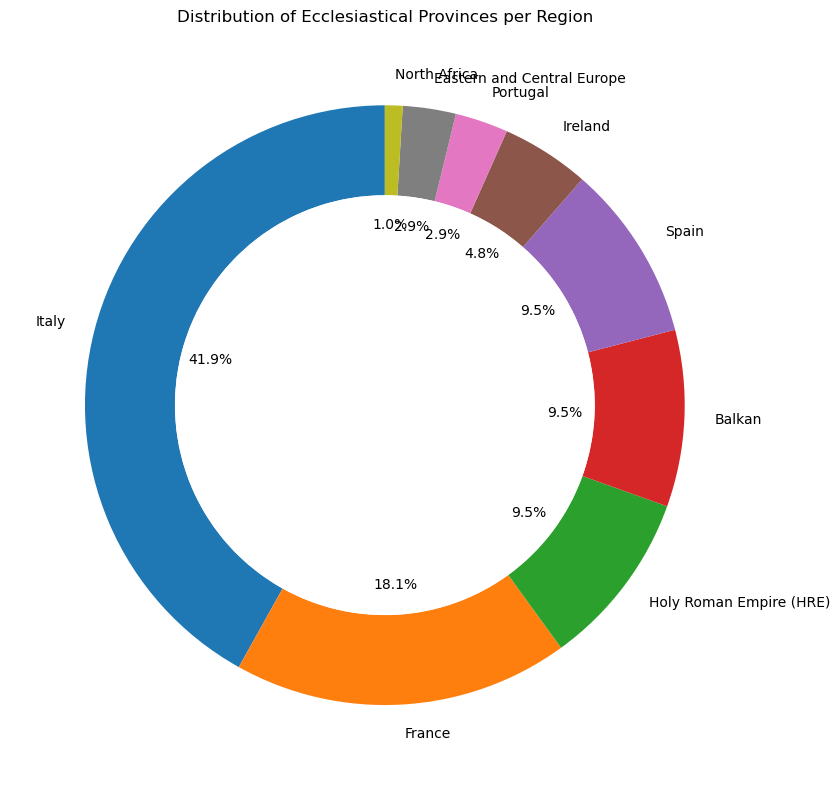

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.pie(sparql_provinces_overview_df['ECCLESIASTICAL_PROVINCES'], labels=sparql_provinces_overview_df['REGION'], autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3})

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax.set_title('Distribution of Ecclesiastical Provinces per Region')
plt.tight_layout()
plt.show()

### <font color="blue">4.2 Dioceses and territorial regions</font>

The following query enables a more detailed view of the information presented above. In addition to the ecclesiastical province (i.e. the archdiocese), it also displays the dioceses belonging to each province. These dioceses are recorded both in the marginal notes and again in the main entry.

In [ ]:
sparql_dioceses_overview = """
# SPARQL query: number of dioceses per territorial region (Expedit. 2 and 9)
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?DIOCESE_1) AS ?DIOCESES) ?ECCLESIASTICAL_PROVINCE ?REGION WHERE {
  ?DIOCESE_1 rdf:type grace:diocese;
    grace:called ?DIOCESE_1_label;
    (grace:under_jurisdiction+) ?ECCLESIASTICAL_PROVINCE_2.
  ?ECCLESIASTICAL_PROVINCE_2 rdf:type grace:ecclesiastical_province;
    grace:called ?ECCLESIASTICAL_PROVINCE.
  ?DIOCESE_1 grace:primary_place ?PLACE_4.
  ?PLACE_4 rdf:type grace:place;
    (grace:falls_within+) ?REGION_6.
  ?REGION_6 rdf:type grace:region;
    grace:called ?REGION.
  ?DIOCESE_1 grace:holds_object ?OBJECT_8.
  ?OBJECT_8 rdf:type grace:object;
    grace:object_related_to_event ?EVENT_10.
  ?EVENT_10 rdf:type grace:event;
    grace:testified_by ?ENTRY_12.
  ?ENTRY_12 rdf:type grace:entry;
    grace:in_source ?SOURCE_14.
  VALUES ?SOURCE_14 {
    g17:source_1
    g17:source_2
  }
}
GROUP BY ?ECCLESIASTICAL_PROVINCE_2 ?ECCLESIASTICAL_PROVINCE ?REGION_6 ?REGION
ORDER BY DESC (?DIOCESES)
"""

In [32]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_dioceses_overview)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### <font color="blue">4.3 Places and territorial regions</font>

The next query diplays the number of places per region. With places we refer to cities or any human settlement we identified in the *Expeditiones* registers 2 and 9. These are usually the location (primary place) of the dioceses where offices were assigned.

In [33]:
sparql_places_overview = """
# SPARQL query: number of places per territorial region (Expedit.2 and 9)
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT (COUNT(DISTINCT ?PLACE_1) AS ?PLACES) ?REGION WHERE {
  ?PLACE_1 rdf:type grace:place;
    grace:called ?PLACE_1_label;
    (grace:falls_within+) ?REGION_2.
  ?REGION_2 rdf:type grace:region;
    grace:called ?REGION.
  ?PLACE_1 ^grace:primary_place ?INSTITUTION_4.
  ?INSTITUTION_4 rdf:type grace:institution;
    grace:holds_object ?OBJECT_6.
  ?OBJECT_6 rdf:type grace:object;
    grace:object_related_to_event ?EVENT_8.
  ?EVENT_8 rdf:type grace:event;
    (grace:testified_by/grace:in_source) ?SOURCE_10.
  VALUES ?SOURCE_10 {
    g17:source_1
    g17:source_2
  }
}
GROUP BY ?REGION_2 ?REGION
ORDER BY DESC (?PLACES)
"""
sparql_places_overview_df=dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_places_overview)

In [34]:
sparql_places_overview_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


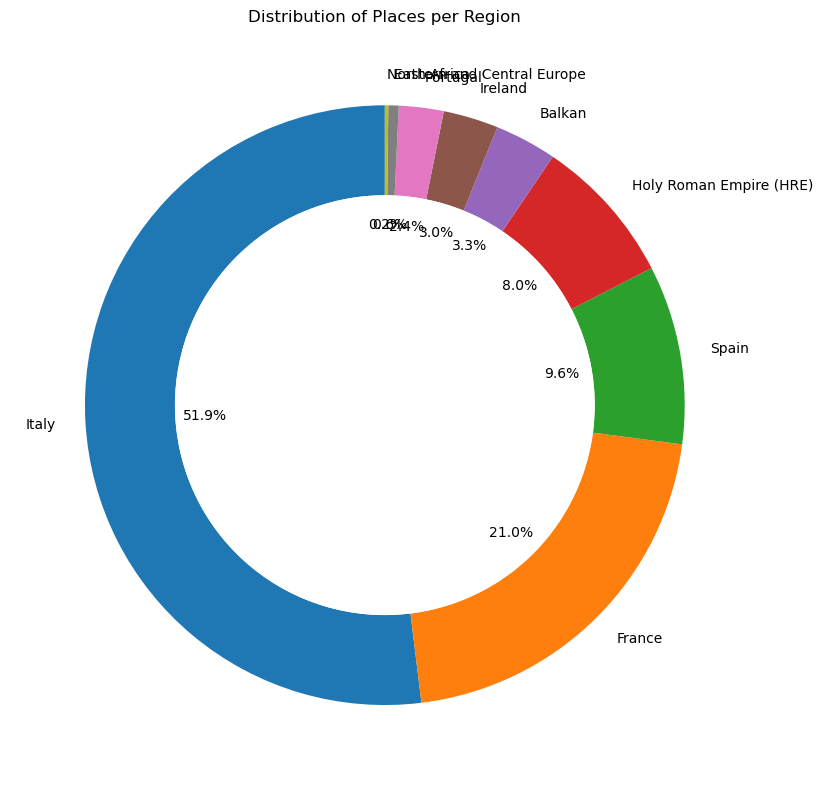

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.pie(sparql_places_overview_df['PLACES'], labels=sparql_places_overview_df['REGION'], autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3})

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax.set_title('Distribution of Places per Region')
plt.tight_layout()
plt.show()

### <font color="blue">4.4 Geographical location of dioceses</font>

The following view presents all primary locations — that is, the seats of bishops — as well as the institutions linked to them and the corresponding institutional types.

In [36]:
sparql_geographical_location_of_the_dioceses = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX g17: <https://g17.dhi-roma.it/resources/>
PREFIX grace: <https://w3id.org/grace/ontology/>
SELECT DISTINCT ?MAP ?PLACE ?INSTITUTION ?TYPE WHERE {
  ?EVENT_1 rdf:type grace:event;
    grace:event_related_to_object ?OBJECT_2.
  ?OBJECT_2 rdf:type grace:object;
    grace:in_diocese ?INSTITUTION_3.
  ?INSTITUTION_3 rdf:type grace:institution;
    grace:called ?INSTITUTION;
    grace:primary_place ?PLACE_5.
  ?PLACE_5 rdf:type grace:place;
    grace:called ?PLACE;
    grace:wkt ?MAP.
  ?OBJECT_2 grace:in_diocese ?INSTITUTION_12.
  ?INSTITUTION_12 rdf:type grace:institution;
    grace:has_main_type ?TYPE_14.
  ?TYPE_14 rdf:type grace:type;
    grace:called ?TYPE.
  ?EVENT_1 grace:testified_by ?ENTRY_8.
  ?ENTRY_8 rdf:type grace:entry;
    grace:in_source ?SOURCE_10.
  VALUES ?SOURCE_10 {
    g17:source_2
    g17:source_1
  }
}
ORDER BY (?PLACE)
"""

In [37]:
dataria.DATA.sparql_to_dataframe(endpoint_url=endpoint_url,query=sparql_geographical_location_of_the_dioceses)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [46]:
dataria.GEO.explore(
    endpoint_url=endpoint_url, # as defined above
    query=sparql_geographical_location_of_the_dioceses, # as defined above
    geo_var="MAP", # the name of the variable in the query that return the coordinates
    label_var="INSTITUTION", # the query variable for label for the entity shown on the map
    cmap='tab10',
    cluster_weight_var='TYPE' # the variable to use for clustering
    )